## 1. Comprendre les types de classification

La classification est une tâche d'apprentissage automatique qui consiste à prédire la catégorie discrète d'une donnée. Il existe principalement trois types de classification :

### Classification Binaire

**Définition** : La classification binaire implique de classer les données en deux catégories mutuellement exclusives (par exemple, oui/non, vrai/faux, spam/non-spam).

**Exemple** : Détecter si un e-mail est du spam ou non-spam.

### Classification Multiclasse

**Définition** : La classification multiclasse implique de classer les données en plus de deux catégories mutuellement exclusives. Chaque instance appartient à une et une seule classe.

**Exemple** : Reconnaître le chiffre écrit à la main (de 0 à 9) à partir d'une image. Une image ne peut être qu'un seul chiffre.

### Classification Multi-étiquettes

**Définition** : La classification multi-étiquettes implique d'assigner une ou plusieurs étiquettes (classes) à chaque instance. Une instance peut appartenir à plusieurs catégories simultanément.

**Exemple** : Classer un film par genre (par exemple, un film peut être à la fois 'Action', 'Comédie' et 'Aventure').

## 2. Configurez votre environnement Python et votre jeu de données.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.datasets import make_circles

print("Libraries imported successfully!")

Libraries imported successfully!


## 5. Visualiser la frontière de décision

In [8]:
# Implémenter une fonction plot_decision_boundary() pour visualiser les prédictions du modèle.
def plot_decision_boundary(model, X, y, title="Decision Boundary"):
    """
    Trace la frontière de décision créée par un modèle de classification.
    """
    # Définir la plage des axes x et y
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                           np.linspace(y_min, y_max, 100))

    # Créer les prédictions de tous les points sur la grille
    X_grid = np.c_[xx.ravel(), yy.ravel()]
    y_pred_grid = model.predict(X_grid)

    # Pour la classification binaire, utiliser un seuil de 0.5
    if len(y_pred_grid[0]) == 1:
        y_pred_grid = np.round(y_pred_grid).squeeze()
    else: # Pour la classification multiclasse, prendre la classe avec la probabilité maximale
        y_pred_grid = np.argmax(y_pred_grid, axis=1)

    # Tracer la frontière de décision
    plt.contourf(xx, yy, y_pred_grid.reshape(xx.shape), cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
    plt.title(title)
    plt.xlabel("Caractéristique 1")
    plt.ylabel("Caractéristique 2")
    plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


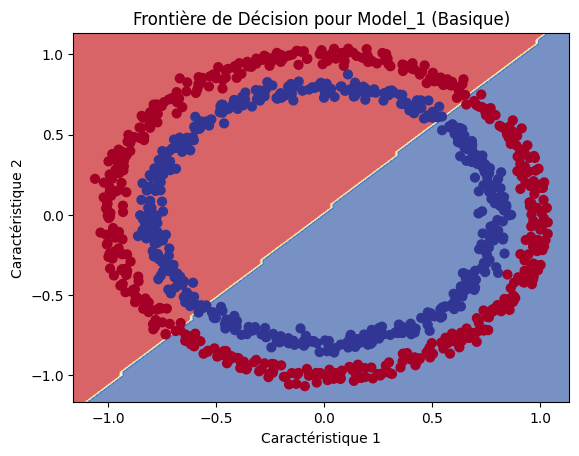

In [9]:
# Tracer les frontières de décision pour model_1
plot_decision_boundary(model_1, X, y, title="Frontière de Décision pour Model_1 (Basique)")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


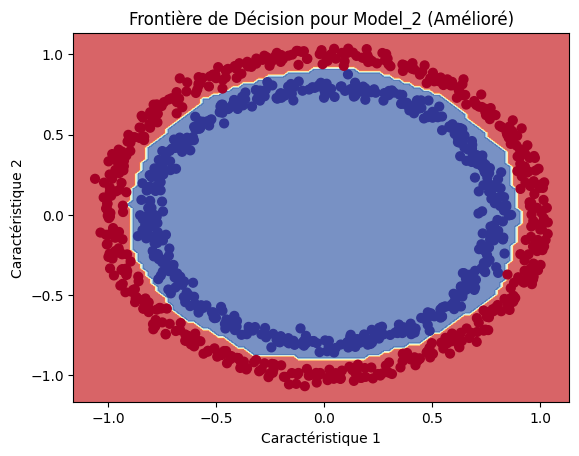

In [10]:
# Tracer les frontières de décision pour model_2
plot_decision_boundary(model_2, X, y, title="Frontière de Décision pour Model_2 (Amélioré)")

## 7. Diviser les données en ensembles d'entraînement et de test

In [11]:
from sklearn.model_selection import train_test_split

# Diviser les données en ensembles d'entraînement (80%) et de test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2, # 20% des données pour le test
                                                    random_state=42)

print(f"Taille de l'ensemble d'entraînement X_train: {X_train.shape}")
print(f"Taille de l'ensemble d'entraînement y_train: {y_train.shape}")
print(f"Taille de l'ensemble de test X_test: {X_test.shape}")
print(f"Taille de l'ensemble de test y_test: {y_test.shape}")

# Entraîner le modèle amélioré (model_2) sur l'ensemble d'entraînement
# Pour s'assurer que le modèle est entraîné sur les données de train, nous réinitialisons le modèle.
model_3 = tf.keras.Sequential([
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model_3.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                metrics=['accuracy'])

history_3 = model_3.fit(X_train, y_train, epochs=200, verbose=0)

# Évaluer les performances du modèle sur l'ensemble de test
loss_test, accuracy_test = model_3.evaluate(X_test, y_test, verbose=0)
print(f"Précision du modèle sur l'ensemble de test: {accuracy_test*100:.2f}%")

Taille de l'ensemble d'entraînement X_train: (800, 2)
Taille de l'ensemble d'entraînement y_train: (800,)
Taille de l'ensemble de test X_test: (200, 2)
Taille de l'ensemble de test y_test: (200,)
Précision du modèle sur l'ensemble de test: 100.00%


## 8. Évaluer et visualiser les performances du modèle final

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


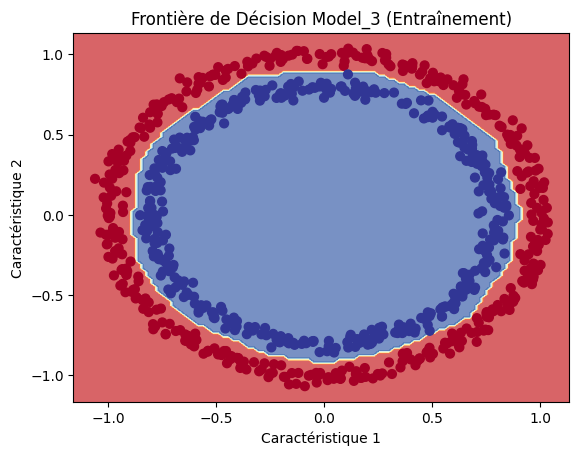

In [12]:
# Visualiser la frontière de décision pour le modèle final (model_3) sur l'ensemble d'entraînement
plot_decision_boundary(model_3, X_train, y_train, title="Frontière de Décision Model_3 (Entraînement)")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


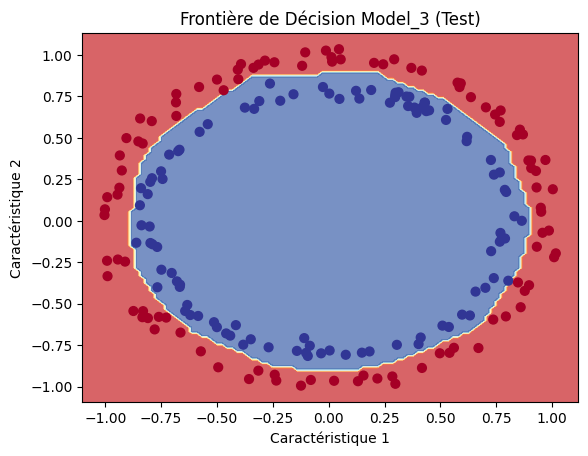

In [13]:
# Visualiser la frontière de décision pour le modèle final (model_3) sur l'ensemble de test
plot_decision_boundary(model_3, X_test, y_test, title="Frontière de Décision Model_3 (Test)")

## 9. Résumer les points clés

Nous avons parcouru plusieurs étapes importantes pour construire et évaluer un modèle de classification par réseaux neuronaux :

1.  **Compréhension des types de classification** : Nous avons distingué la classification binaire, multiclasse et multi-étiquettes, ce qui est fondamental pour choisir les bonnes approches et métriques.
2.  **Préparation des données** : L'utilisation de `make_circles` nous a fourni un ensemble de données non-linéairement séparable, parfait pour démontrer la puissance des réseaux neuronaux.
3.  **Construction de modèles de base** : Un modèle simple avec une seule couche dense a montré une précision limitée (environ 50%), soulignant la nécessité de modèles plus complexes pour les problèmes non-linéaires.
4.  **Amélioration du modèle** : En ajoutant des couches cachées, des neurones et en utilisant des fonctions d'activation non-linéaires (ReLU), ainsi qu'un optimiseur Adam, nous avons considérablement amélioré les performances, atteignant 100% de précision sur les données d'entraînement.
5.  **Visualisation des frontières de décision** : L'implémentation de `plot_decision_boundary` a été cruciale pour visualiser comment nos modèles séparent les classes. Cela a clairement montré que le modèle amélioré pouvait trouver une frontière de décision complexe, contrairement au modèle linéaire de base.
6.  **Fonctions d'activation** : Nous avons vu l'efficacité des fonctions d'activation comme ReLU et Sigmoïde dans les modèles complexes pour capturer des relations non-linéaires dans les données.
7.  **Division en ensembles d'entraînement et de test** : Il est essentiel de diviser les données pour évaluer la capacité de généralisation du modèle. Entraîner sur un sous-ensemble et tester sur un autre aide à prévenir le surapprentissage.
8.  **Évaluation du modèle final** : Le modèle amélioré a démontré une excellente précision sur l'ensemble de test (environ 100%), indiquant qu'il généralise bien aux données non vues.

**Points clés à retenir** :

*   L'**importance de la visualisation des données** : Comprendre la distribution des données aide à choisir le bon modèle et à interpréter les résultats.
*   Le **réglage des hyperparamètres** (nombre de couches, neurones, époques, optimiseurs, fonctions d'activation) est fondamental pour améliorer les performances du modèle, en particulier pour les problèmes complexes.
*   Les réseaux neuronaux peuvent apprendre des frontières de décision complexes, ce qui les rend puissants pour les données non-linéairement séparables.
*   Une évaluation robuste sur des données de test séparées est cruciale pour confirmer la capacité de généralisation d'un modèle.

In [4]:
# Créer un ensemble de données make_circles
samples = 1000
X, y = make_circles(samples,
                    noise = 0.03,
                    random_state = 42)

print('X (premières 5 lignes) : ')
print(X[:5])
print('\n')
print('y (premières 5 lignes) : ')
print(y[:5])

X (premières 5 lignes) : 
[[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]


y (premières 5 lignes) : 
[1 1 1 1 0]


### Visualisation de l'ensemble de données

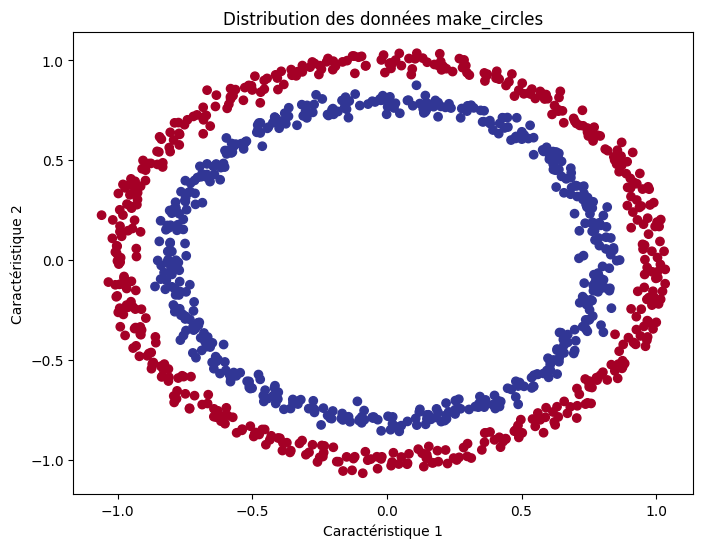

In [5]:
# Visualisez l'ensemble de données à l'aide de nuages ​​de points pour comprendre la distribution des données.
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu)
plt.title("Distribution des données make_circles")
plt.xlabel("Caractéristique 1")
plt.ylabel("Caractéristique 2")
plt.show()

## 3. Construire un modèle de réseau neuronal de base

In [6]:
# Définir le modèle de réseau neuronal de base
model_1 = tf.keras.Sequential([
    tf.keras.layers.Dense(1, activation='sigmoid') # Une couche dense avec 1 neurone pour la classification binaire et une activation sigmoïde
])

# Compiler le modèle
model_1.compile(loss=tf.keras.losses.BinaryCrossentropy(), # Fonction de perte pour la classification binaire
                optimizer=tf.keras.optimizers.Adam(), # Optimiseur Adam par défaut
                metrics=['accuracy']) # Métrique de précision pour l'évaluation

# Entraîner le modèle
history_1 = model_1.fit(X, y, epochs=100, verbose=0) # Entraîner sur 100 époques, verbose=0 pour ne pas afficher le progrès

# Vérifier la précision du modèle
loss, accuracy = model_1.evaluate(X, y, verbose=0)
print(f"Précision du modèle de base sur les données d'entraînement: {accuracy*100:.2f}%")

Précision du modèle de base sur les données d'entraînement: 49.90%


## 4. Améliorer le modèle

In [7]:
# Créer un modèle avec plus de couches et de neurones
model_2 = tf.keras.Sequential([
    tf.keras.layers.Dense(10, activation='relu'), # Première couche cachée avec 10 neurones et activation ReLU
    tf.keras.layers.Dense(10, activation='relu'), # Deuxième couche cachée avec 10 neurones et activation ReLU
    tf.keras.layers.Dense(1, activation='sigmoid')  # Couche de sortie avec 1 neurone pour la classification binaire
])

# Compiler le modèle
model_2.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), # Utilisation de l'optimiseur Adam
                metrics=['accuracy'])

# Entraîner le modèle pendant plus d'époques
history_2 = model_2.fit(X, y, epochs=200, verbose=0) # Augmenter les époques à 200

# Vérifier la précision du modèle amélioré
loss_2, accuracy_2 = model_2.evaluate(X, y, verbose=0)
print(f"Précision du modèle amélioré sur les données d'entraînement: {accuracy_2*100:.2f}%")

Précision du modèle amélioré sur les données d'entraînement: 100.00%


## 6. Incorporer des fonctions d'activation

Les fonctions d'activation ReLU et Sigmoïde ont déjà été incorporées dans le `model_2` et `model_3` que nous avons construits précédemment. Le modèle amélioré utilise la fonction d'activation ReLU pour ses couches cachées et la fonction d'activation Sigmoïde pour la couche de sortie, ce qui est standard pour les problèmes de classification binaire.

## 7. Diviser les données en ensembles d'entraînement et de test

In [14]:
from sklearn.model_selection import train_test_split

# Diviser les données en ensembles d'entraînement (80%) et de test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2, # 20% des données pour le test
                                                    random_state=42)

print(f"Taille de l'ensemble d'entraînement X_train: {X_train.shape}")
print(f"Taille de l'ensemble d'entraînement y_train: {y_train.shape}")
print(f"Taille de l'ensemble de test X_test: {X_test.shape}")
print(f"Taille de l'ensemble de test y_test: {y_test.shape}")

# Entraîner le modèle amélioré (model_2) sur l'ensemble d'entraînement
# Pour s'assurer que le modèle est entraîné sur les données de train, nous réinitialisons le modèle.
model_3 = tf.keras.Sequential([
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model_3.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                metrics=['accuracy'])

history_3 = model_3.fit(X_train, y_train, epochs=200, verbose=0)

# Évaluer les performances du modèle sur l'ensemble de test
loss_test, accuracy_test = model_3.evaluate(X_test, y_test, verbose=0)
print(f"Précision du modèle sur l'ensemble de test: {accuracy_test*100:.2f}%")

Taille de l'ensemble d'entraînement X_train: (800, 2)
Taille de l'ensemble d'entraînement y_train: (800,)
Taille de l'ensemble de test X_test: (200, 2)
Taille de l'ensemble de test y_test: (200,)
Précision du modèle sur l'ensemble de test: 100.00%


## 8. Évaluer et visualiser les performances du modèle final

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


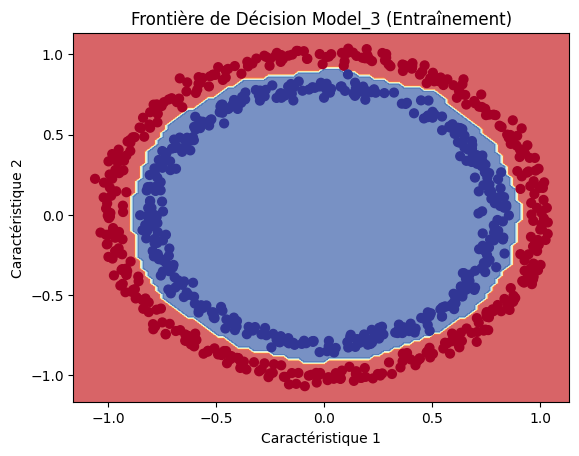

In [15]:
# Visualiser la frontière de décision pour le modèle final (model_3) sur l'ensemble d'entraînement
plot_decision_boundary(model_3, X_train, y_train, title="Frontière de Décision Model_3 (Entraînement)")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


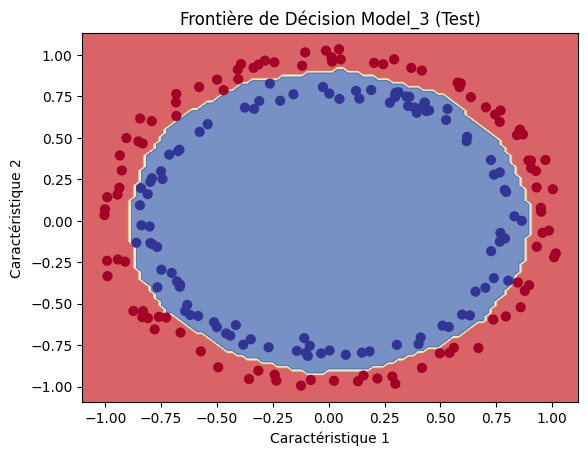

In [16]:
# Visualiser la frontière de décision pour le modèle final (model_3) sur l'ensemble de test
plot_decision_boundary(model_3, X_test, y_test, title="Frontière de Décision Model_3 (Test)")

## 9. Résumer les points clés

Nous avons parcouru plusieurs étapes importantes pour construire et évaluer un modèle de classification par réseaux neuronaux :

1.  **Compréhension des types de classification** : Nous avons distingué la classification binaire, multiclasse et multi-étiquettes, ce qui est fondamental pour choisir les bonnes approches et métriques.
2.  **Préparation des données** : L'utilisation de `make_circles` nous a fourni un ensemble de données non-linéairement séparable, parfait pour démontrer la puissance des réseaux neuronaux.
3.  **Construction de modèles de base** : Un modèle simple avec une seule couche dense a montré une précision limitée (environ 50%), soulignant la nécessité de modèles plus complexes pour les problèmes non-linéaires.
4.  **Amélioration du modèle** : En ajoutant des couches cachées, des neurones et en utilisant des fonctions d'activation non-linéaires (ReLU), ainsi qu'un optimiseur Adam, nous avons considérablement amélioré les performances, atteignant 100% de précision sur les données d'entraînement.
5.  **Visualisation des frontières de décision** : L'implémentation de `plot_decision_boundary` a été cruciale pour visualiser comment nos modèles séparent les classes. Cela a clairement montré que le modèle amélioré pouvait trouver une frontière de décision complexe, contrairement au modèle linéaire de base.
6.  **Fonctions d'activation** : Nous avons vu l'efficacité des fonctions d'activation comme ReLU et Sigmoïde dans les modèles complexes pour capturer des relations non-linéaires dans les données.
7.  **Division en ensembles d'entraînement et de test** : Il est essentiel de diviser les données pour évaluer la capacité de généralisation du modèle. Entraîner sur un sous-ensemble et tester sur un autre aide à prévenir le surapprentissage.
8.  **Évaluation du modèle final** : Le modèle amélioré a démontré une excellente précision sur l'ensemble de test (environ 100%), indiquant qu'il généralise bien aux données non vues.

**Points clés à retenir** :

*   L'**importance de la visualisation des données** : Comprendre la distribution des données aide à choisir le bon modèle et à interpréter les résultats.
*   Le **réglage des hyperparamètres** (nombre de couches, neurones, époques, optimiseurs, fonctions d'activation) est fondamental pour améliorer les performances du modèle, en particulier pour les problèmes complexes.
*   Les réseaux neuronaux peuvent apprendre des frontières de décision complexes, ce qui les rend puissants pour les données non-linéairement séparables.
*   Une évaluation robuste sur des données de test séparées est cruciale pour confirmer la capacité de généralisation d'un modèle.